In [1]:
!pip  install pandas

In [2]:
import pandas as pd 
import numpy as np
#fist we will  the csv file for the koacl machine 
df=pd.read_csv("Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [6]:
# categorical feature 
cat_features=[ i for i in df.columns if df[i].dtype=="O"]
num_features=[i for i in df.columns if df[i].dtype!="O"]

In [7]:
df.head(1)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.0,1,1,1,101348.88,1


In [8]:
!pip  install matplotlib

In [9]:
!pip  install seaborn

<Axes: xlabel='Geography', ylabel='Exited'>

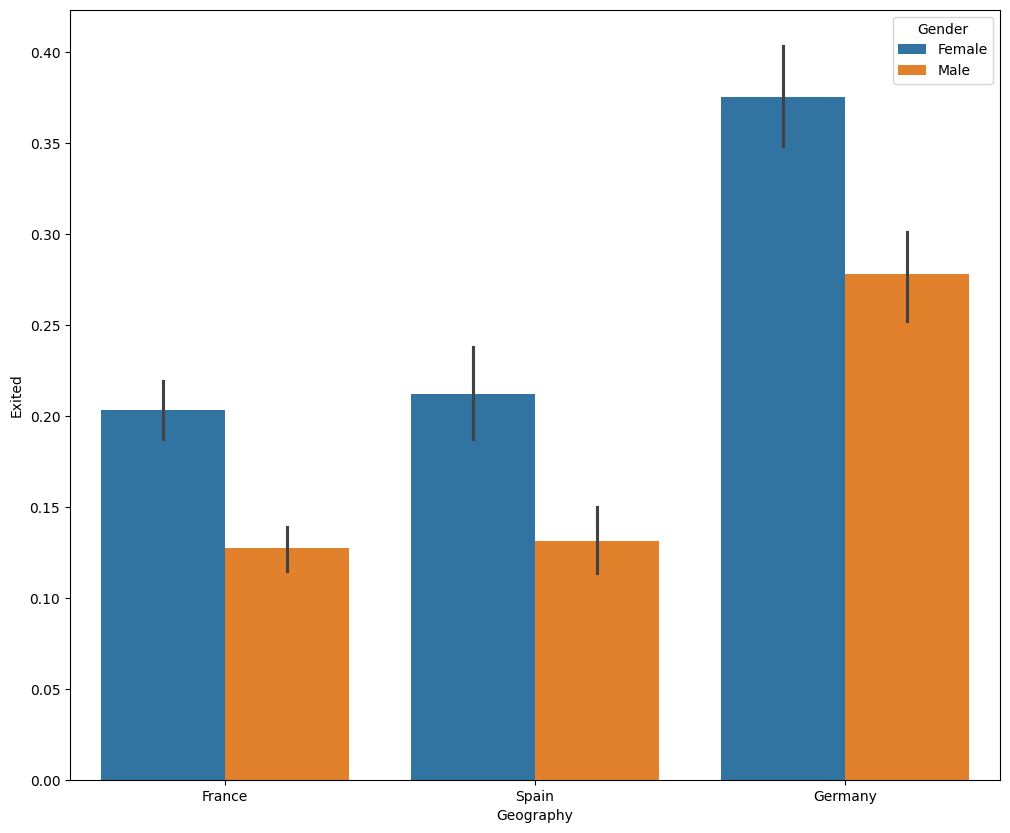

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt 
plt.figure(figsize=(12,10))
sns.barplot(x=df['Geography'],y=df['Exited'],hue=df['Gender'],estimator='mean')

In [11]:
sns.pairplot(df,kind='hist')

Error in callback <function flush_figures at 0x000002E81A039120> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [ ]:
df.groupby(df['Gender'])['CreditScore'].sum()

Gender
Female    2956727
Male      3548561
Name: CreditScore, dtype: int64

In [ ]:
l1=df.groupby('Gender')['Exited'].count().reset_index()

C:\Users\HP\AppData\Local\Temp\ipykernel_4628\3771641297.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=l1['Gender'],x=l1['Exited'],palette='hls',orient='h')


<Axes: xlabel='Exited', ylabel='Gender'>

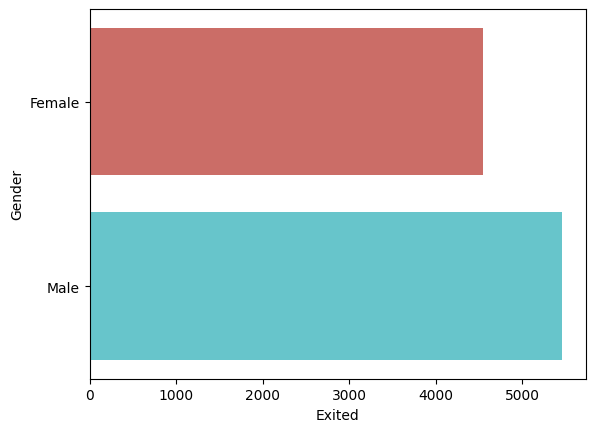

In [ ]:
sns.barplot(y=l1['Gender'],x=l1['Exited'],palette='hls',orient='h')

(array([  19.,  166.,  447.,  958., 1444., 1866., 1952., 1525.,  968.,
         655.]),
 array([350., 400., 450., 500., 550., 600., 650., 700., 750., 800., 850.]),
 <BarContainer object of 10 artists>)

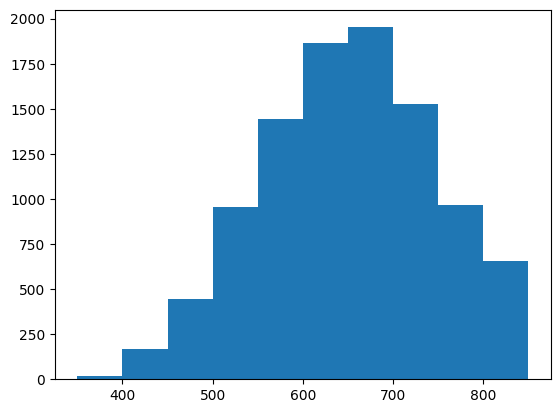

In [ ]:
plt.hist(df['CreditScore'])

([<matplotlib.patches.Wedge at 0x1d4aba1ef10>,
 [Text(-0.8823432229396718, 0.656864093197697, 'Not Exited'),
  Text(0.9785987372565915, -0.728522142038116, 'Exited')],
 [Text(-0.4812781216034573, 0.358289505380562, '79.6%'),
  Text(0.57753368100389, -0.42994749366183893, '20.4%')])

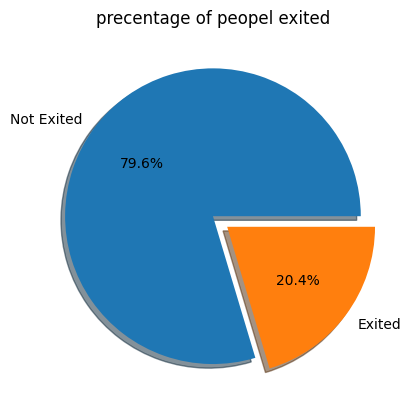

In [ ]:

plt.title("precentage of peopel exited")
plt.pie(x=df['Exited'].value_counts()/10000*100,labels=['Not Exited','Exited'],autopct='%1.1f%%',explode=[0,0.12],shadow=True)
#interpretation
# 20.4 percentage of people have exited from the bank remaining 79,6% are still there

<Axes: xlabel='CreditScore', ylabel='Exited'>

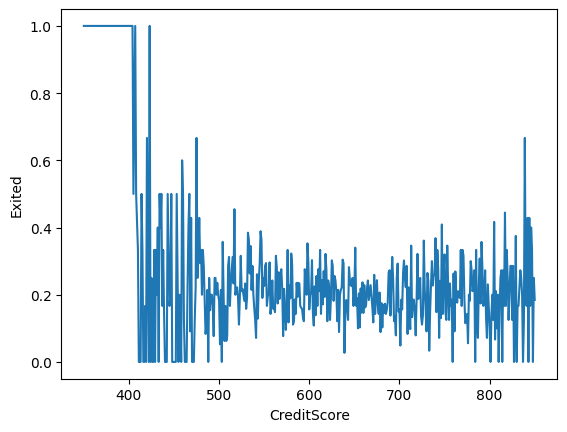

In [ ]:
sns.lineplot(
    x=df["CreditScore"],
    y=df["Exited"],
    estimator="mean",
    errorbar=None
)
# the people having the credit the score between the 5000 to 800 are least like to leave the bank 

<Axes: xlabel='CreditScore', ylabel='Count'>

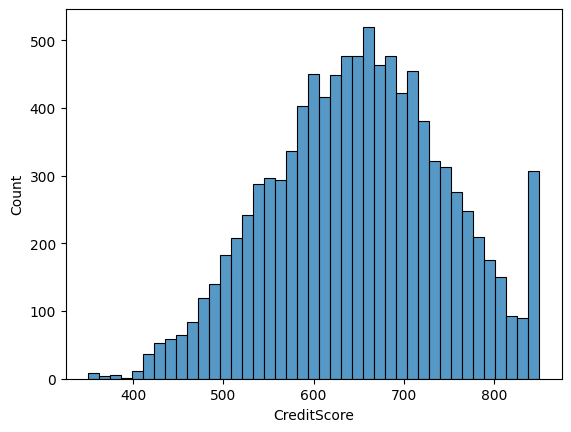

In [12]:
sns.histplot(df['CreditScore'])
# There are more no of people having cedit score between 600 to 700.......

In [13]:
# how many peopel have exited the account from bank in each of the country

l2=df.groupby(['Geography','Gender'])['Exited'].count().reset_index()

l2

,Geography,Gender,Exited
0,France,Female,2261
1,France,Male,2753
2,Germany,Female,1193
3,Germany,Male,1316
4,Spain,Female,1089
5,Spain,Male,1388


<Axes: xlabel='Exited', ylabel='Geography'>

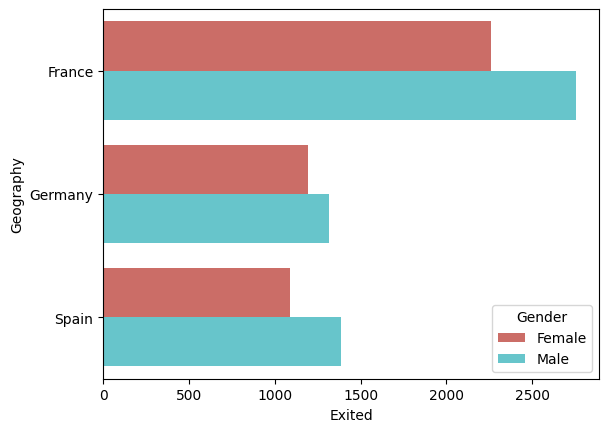

In [14]:
sns.barplot(y=l2['Geography'],x=l2['Exited'],hue=l2['Gender'],palette='hls')
# interpretation
# There are more no of peopel in france who have exited from the bank in wich 2261 are female and 2753 are male
# follwed by germany and spain.

In [15]:
df.groupby(['Gender','HasCrCard'])['Exited'].count().reset_index()

,Gender,HasCrCard,Exited
0,Female,0,1351
1,Female,1,3192
2,Male,0,1594
3,Male,1,3863


In [16]:
df.drop(['RowNumber','CustomerId','Surname'],axis=1,inplace=True)

In [17]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [18]:
from sklearn.preprocessing import LabelEncoder
gen_enocoder=LabelEncoder()

df['Gender']=gen_enocoder.fit_transform(df['Gender'])

In [19]:
from sklearn.preprocessing import OneHotEncoder

encoder=OneHotEncoder()
encoded=encoder.fit_transform(pd.DataFrame(df['Geography']))

In [20]:
df=pd.concat([df,pd.DataFrame(encoded.toarray(),columns=encoder.get_feature_names_out())],axis=1)
df.head()
# encoder.get_feature_names_out()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,France,0,42,2,0.00,1,1,1,101348.88,1,1.0,0.0,0.0
1,608,Spain,0,41,1,83807.86,1,0,1,112542.58,0,0.0,0.0,1.0
2,502,France,0,42,8,159660.80,3,1,0,113931.57,1,1.0,0.0,0.0
3,699,France,0,39,1,0.00,2,0,0,93826.63,0,1.0,0.0,0.0
4,850,Spain,0,43,2,125510.82,1,1,1,79084.10,0,0.0,0.0,1.0


In [21]:
df.drop('Geography',axis=1,inplace=True)

In [33]:
#we will  store the encoder in the pickle file 
import pickle

with open('gen_encoder.pkl','wb') as file:
    pickle.dump(gen_enocoder,file)

with open('geo_encoder.pkl','wb') as file:
    pickle.dump(encoder,file)

In [34]:
#test train split and standardation of the datafame
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x=df.drop("Exited",axis=1)
y=df['Exited']

x_train,x_test,y_tarin,y_test=train_test_split(x,y,test_size=0.2)

x_train

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain
4698,732,1,62,2,0.00,2,1,1,25438.87,1.0,0.0,0.0
1537,821,0,28,8,0.00,1,1,1,36754.13,1.0,0.0,0.0
7501,681,0,58,8,93173.88,1,1,1,139761.25,1.0,0.0,0.0
9112,735,1,73,9,0.00,1,1,1,114283.33,1.0,0.0,0.0
4451,578,1,34,4,175111.11,1,1,1,74858.30,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2128,743,1,37,8,69143.91,2,0,1,105780.18,1.0,0.0,0.0
7418,677,1,36,4,0.00,2,1,0,7824.31,1.0,0.0,0.0
6358,652,0,32,2,0.00,2,1,0,54628.11,1.0,0.0,0.0
5510,588,0,48,1,143279.58,2,1,0,31580.80,0.0,1.0,0.0


In [35]:
scalar=StandardScaler()

x_train_scaled=scalar.fit_transform(x_train)
x_test_scaled=scalar.transform(x_test)

In [36]:
with open('scalar.pkl','wb') as file:
    pickle.dump(scalar,file)


In [ ]:
!pip  install tensorflow 


  Using cached wrapt-2.0.1-cp311-cp311-win_amd64.whl.metadata (9.2 kB)
   ---------------------------------------- 0.0/331.8 MB ? eta -:--:--
   ---------------------------------------- 0.5/331.8 MB 3.4 MB/s eta 0:01:39
   ---------------------------------------- 1.0/331.8 MB 3.1 MB/s eta 0:01:46
   ---------------------------------------- 1.8/331.8 MB 3.0 MB/s eta 0:01:52
   ---------------------------------------- 2.4/331.8 MB 3.0 MB/s eta 0:01:51
   ---------------------------------------- 3.1/331.8 MB 3.0 MB/s eta 0:01:51
   ---------------------------------------- 3.7/331.8 MB 3.0 MB/s eta 0:01:50
    --------------------------------------- 4.2/331.8 MB 3.0 MB/s eta 0:01:50
    --------------------------------------- 4.7/331.8 MB 3.0 MB/s eta 0:01:51
    --------------------------------------- 5.2/331.8 MB 2.7 MB/s eta 0:02:00
    --------------------------------------- 5.5/331.8 MB 2.6 MB/s eta 0:02:06
    --------------------------------------- 6.0/331.8 MB 2.6 MB/s eta 0:02:05


In [24]:
import tensorflow as tf
from tensorflow.keras.layers import Dense # type: ignore
from tensorflow.keras.models import  Sequential
from tensorflow.keras.callbacks import EarlyStopping,TensorBoard
import datetime
model=Sequential(
    [ Dense(64,activation='relu',input_shape=(x_test_scaled.shape[1],)),
    Dense(32,activation='relu'),
    Dense(1,activation='sigmoid'),
    ]
)

d:\ANN_project\venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):
d:\ANN_project\venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# forward and the backward propagation 

# compliation of the  model 
model.compile(optimizer='Adam',loss='binary_crossentropy',metrics=['accuracy'])

In [27]:
##setup tensor board

log_dir="logs/fit"+datetime.datetime.now().strftime('%Y%m%d-%H%M%S')
tensorflow_callback=TensorBoard(log_dir=log_dir,histogram_freq=1)

In [ ]:
#Setup Early Stopping
early_stopping_callback=EarlyStoppingpatience=5(monitor='val_loss',,restore_best_weights=True)


In [29]:
# train the molde

history=model.fit(x_train_scaled,y_tarin,validation_data=(x_test_scaled,y_test),epochs=100,
                  callbacks=[tensorflow_callback,early_stopping_callback])

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8045 - loss: 0.4456 - val_accuracy: 0.8150 - val_loss: 0.4238
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8479 - loss: 0.3769 - val_accuracy: 0.8370 - val_loss: 0.3880
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8622 - loss: 0.3455 - val_accuracy: 0.8340 - val_loss: 0.3780
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8645 - loss: 0.3355 - val_accuracy: 0.8330 - val_loss: 0.3768
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8661 - loss: 0.3295 - val_accuracy: 0.8445 - val_loss: 0.3690
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8694 - loss: 0.3247 - val_accuracy: 0.8465 - val_loss: 0.3677
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8681 - loss: 0.3239 - val_accuracy: 0.8410 - val_loss: 0.3694
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8698 - loss: 0.3209 - val_accu

In [ ]:
model.save('model.h5')

In [30]:
## load tensorboard extension
%load_ext tensorboard

In [31]:
# %tensorboard --logdir logs/fit


kill: 14576: No such process


In [ ]:
### load pickle file


In [37]:
df['CreditScore'].max()

np.int64(850)